<a href="https://colab.research.google.com/github/IAISA/neur265/blob/main/Coding_Homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Imaan Ali
*NEUR 265*

**4/6/26**

In [76]:
#import libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy
from scipy.stats import pearsonr
import matplotlib as mpl
from matplotlib.ticker import FixedLocator
from matplotlib.colorbar import Colorbar
from skimage import io
import matplotlib.ticker as mticker
import os
import random
import time
from matplotlib import gridspec
from pandas import DataFrame as df
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from statsmodels.genmod.families.links import identity, log
from scipy.stats import chi2
from statsmodels.distributions.empirical_distribution import ECDF

In [77]:
#import files as numpy arrays
url1 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv'
url2 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv'
url3 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv'
url4 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv'

fear_traces = np.loadtxt(url1, delimiter = ',')
extinction_predictors = np.loadtxt(url2, delimiter = ',')
shock_index = np.loadtxt(url3, delimiter=',').astype(int)
tone_index = np.loadtxt(url4, delimiter=',').astype(int)

In [78]:
#two new variables
conditioning_traces = fear_traces[:10458, :]
extinction_traces = fear_traces[10458:, :]

In [79]:
#print size of two arrays
print('conditioning traces shape:',conditioning_traces.shape)
print('extinction traces shape:', extinction_traces.shape)

conditioning traces shape: (10458, 63)
extinction traces shape: (14210, 63)


In [80]:
#two new variables with time correspondence
fs = 15

time_conditioning = np.arange(conditioning_traces.shape[0])/fs
time_extinction = np.arange(extinction_traces.shape[0])/fs

print('time_conditioning:', time_conditioning)

time_conditioning: [0.00000000e+00 6.66666667e-02 1.33333333e-01 ... 6.97000000e+02
 6.97066667e+02 6.97133333e+02]


Question 8:
the number of ROIs was 63. The conditioning session lasted 697.2 secongs which is about 11.62 minutes. The extinction session lasted 947.33 seconds which is about 15.79 minutes.

Text(0, 0.5, 'action')

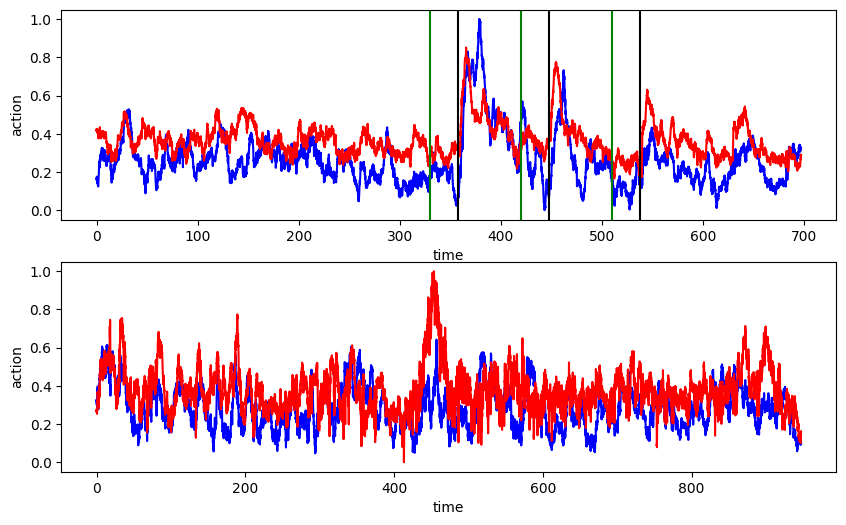

In [81]:
#plotting the ROIs
fig, axs = plt.subplots(2,1, figsize=(10,6))

axs[0].plot(time_conditioning, conditioning_traces[:, 0], color='blue', label='ROI 1')
axs[0].plot(time_conditioning, conditioning_traces[:, 1], color='red', label='ROI 2')

#tone and shock
for t in tone_index:
  axs[0].axvline(t, color = 'green')

for t in shock_index:
  axs[0].axvline(t, color='black')

axs[0].set_xlabel('time')
axs[0].set_ylabel('action')

axs[1].plot(time_extinction, extinction_traces[:, 0], color = 'blue', label = 'ROI 1')
axs[1].plot(time_extinction, extinction_traces[:, 1], color = 'red', label='ROI 2')
axs[1].set_xlabel('time')
axs[1].set_ylabel('action')

Question 10: it seems the both the ROIs have relatively similar patterns. based on the data there may possibly be a correlation here. cells stayed more active during extinction

In [82]:
#shock_array and tone_array as binary vectors
shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

predictors_conditioning = np.column_stack([tone_array, shock_array])


In [83]:
#glm for each ROI using ttone and shock onset as predictors, then store correlations
rois = conditioning_traces.shape[1]
r_index_conditioning=np.zeros(rois)

predictors = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array})

for i in range(rois):
  trace_temp = conditioning_traces[:,i]
  model1 = sm.GLM(trace_temp, predictors, family=Poisson())
  model1_results = model1.fit()
  predicted_trace = model1_results.predict()
  r1 = pearsonr(trace_temp, predicted_trace)
  r_index_conditioning[i] = r1.statistic


In [84]:
#a loop that does the same as the previous but for extinction_traces array
extinction_predictors =extinction_predictors[:14210]
rois_extinction = extinction_traces.shape[1]
r_index_extinction = np.zeros(rois_extinction)

for i in range(rois_extinction):
    trace_temp = extinction_traces[:, i]
    model = sm.GLM(trace_temp, extinction_predictors, family=Poisson())
    model_results = model.fit()
    predicted_trace = model_results.predict()
    r = pearsonr(trace_temp, predicted_trace)
    r_index_extinction[i] = r.statistic

In [85]:
#pearsonr function
r,p = pearsonr(r_index_conditioning, r_index_extinction)
print(r,p)

0.04830630023019471 0.7069458679418128


<function matplotlib.pyplot.show(close=None, block=None)>

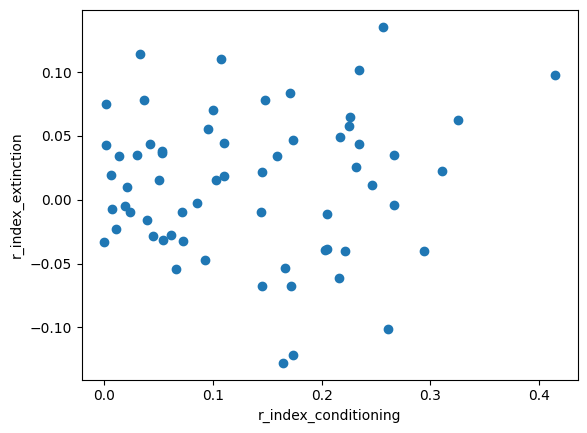

In [86]:
#scatter plot
plt.scatter(r_index_conditioning, r_index_extinction)
plt.xlabel('r_index_conditioning')
plt.ylabel('r_index_extinction')
plt.show

Question 17: there does not seem to be a strong reelationship, the points were widely scattered. So no the tone/shock memory dduring conditioning are not necessarily the same cells that respond during extinction.